## RED NEURONAL CONVOLUCIONAL

En este notebook implementaremos una **Red Neuronal Convolucional (CNN)**. Esta arquitectura aprovecha la jerarquía espacial de las imágenes de Fashion-MNIST mediante una capa convolucional y la operación *Global Average Pooling (GAP).*

In [1]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
from tensorflow.keras.datasets import fashion_mnist
from keras.optimizers import Adam
import random



# 1. Carga de datos
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

# 2. Preprocesamiento: Normalización y Reshape para CNN (28, 28, 1)
X_train_full = X_train_full.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

X_train_full = X_train_full.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# 3. División de datos (Entrenamiento, Validación, Test)
X, X_val, y, y_val = train_test_split(X_train_full, y_train_full,
                                      test_size=0.2, random_state=42,
                                      stratify=y_train_full)

print(f"X (Train): {X.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")

X (Train): (48000, 28, 28, 1), X_val: (12000, 28, 28, 1), X_test: (10000, 28, 28, 1)


In [16]:
import numpy as np
import cv2

def resaltar_caracteristicas_ajustado(X):
    X_3c = np.zeros((X.shape[0], 28, 28, 3), dtype=np.float32)
    
    for i in range(X.shape[0]):
        img = X[i, :, :, 0]
        img_8bit = (img * 255).astype(np.uint8)
        
        # CANAL 0: Original (Mantenemos la información base)
        X_3c[i, :, :, 0] = img
        
        # CANAL 1: Sobel con realce de bordes direccionales
        # Eliminamos el blur previo para no suavizar los botones/texturas
        sx = cv2.Sobel(img, cv2.CV_32F, 1, 0, ksize=3)
        sy = cv2.Sobel(img, cv2.CV_32F, 0, 1, ksize=3)
        mag = np.sqrt(sx**2 + sy**2)
        # Normalización por percentiles para evitar que un píxel brillante opaque el resto
        mag_norm = cv2.normalize(mag, None, 0, 1, cv2.NORM_MINMAX)
        X_3c[i, :, :, 1] = mag_norm
        
        # CANAL 2: Canny con umbrales manuales más agresivos
        # La técnica de la mediana (v) a veces es demasiado alta para imágenes oscuras.
        # Bajamos los umbrales manualmente para "forzar" detalles internos.
        # 30 y 70 son valores experimentales que suelen resaltar botones en Fashion MNIST.
        edges = cv2.Canny(img_8bit, 30, 70) 
        
        # Opcional: Dilatamos un poco los bordes para que la CNN los "vea" mejor
        kernel = np.ones((2,2), np.uint8)
        edges = cv2.dilate(edges, kernel, iterations=1)
        
        X_3c[i, :, :, 2] = edges.astype(np.float32) / 255.0
        
    return X_3c

# Aplicar la transformación ajustada
x_train_3c = resaltar_caracteristicas_ajustado(X)
x_val_3c = resaltar_caracteristicas_ajustado(X_val)
x_test_3c = resaltar_caracteristicas_ajustado(X_test)

In [14]:
import numpy as np
import cv2


def resaltar_caracteristicas_v5_final(X):
    X_3c = np.zeros((X.shape[0], 28, 28, 3), dtype=np.float32)
    
    # Kernel Vertical y Horizontal
    g_vert = cv2.getGaborKernel((5, 5), 1.5, np.pi/2, 5.0, 1.0, 0, ktype=cv2.CV_32F)
    g_horz = cv2.getGaborKernel((5, 5), 1.5, 0, 5.0, 1.0, 0, ktype=cv2.CV_32F)
    
    for i in range(X.shape[0]):
        img = X[i, :, :, 0]
        
        # Canal 0: Original
        X_3c[i, :, :, 0] = img
        
        # Canal 1: Laplaciano Suavizado (Menos ruido de estampado, más cuello/botones)
        blur = cv2.GaussianBlur(img, (3, 3), 0)
        lap = cv2.Laplacian(blur, cv2.CV_32F, ksize=3)
        X_3c[i, :, :, 1] = cv2.normalize(np.abs(lap), None, 0, 1, cv2.NORM_MINMAX)
        
        # Canal 2: Mix de Gabor (vertical + horizontal)
        gv = cv2.filter2D(img, cv2.CV_32F, g_vert)
        gh = cv2.filter2D(img, cv2.CV_32F, g_horz)
        X_3c[i, :, :, 2] = cv2.normalize(gv + gh, None, 0, 1, cv2.NORM_MINMAX)
        
    return np.clip(X_3c, 0, 1)


x_train_3c = resaltar_caracteristicas_v5_final(X)
x_val_3c = resaltar_caracteristicas_v5_final(X_val)
x_test_3c = resaltar_caracteristicas_v5_final(X_test)

In [5]:
import numpy as np
import cv2

def resaltar_caracteristicas_v6_picos(X):
    X_3c = np.zeros((X.shape[0], 28, 28, 3), dtype=np.float32)
    
    # Kernels para detectar estructura Vertical y Horizontal
    g_vert = cv2.getGaborKernel((5, 5), 1.5, np.pi/2, 5.0, 1.0, 0, ktype=cv2.CV_32F)
    g_horz = cv2.getGaborKernel((5, 5), 1.5, 0, 5.0, 1.0, 0, ktype=cv2.CV_32F)
    
    for i in range(X.shape[0]):
        img = X[i, :, :, 0]
        
        # Canal 0: Original
        X_3c[i, :, :, 0] = img
        
        # Canal 1: Laplacian Suavizado (ELIMINA EL PICO DEL CUELLO, DEJA BOTONES)
        # Al aumentar el blur a (5,5), el borde del cuello desaparece de este canal
        blur = cv2.GaussianBlur(img, (5, 5), 0)
        lap = cv2.Laplacian(blur, cv2.CV_32F, ksize=3)
        X_3c[i, :, :, 1] = cv2.normalize(np.abs(lap), None, 0, 1, cv2.NORM_MINMAX)
        
        # Canal 2: Gabor Diferencial (SEPARA APERTURA VERTICAL DE CUELLO DIAGONAL)
        gv = cv2.filter2D(img, cv2.CV_32F, g_vert)
        gh = cv2.filter2D(img, cv2.CV_32F, g_horz)
        
        # La diferencia resalta lo que es puramente vertical (camisa) 
        # y atenúa las diagonales (cuello en V y el pico inferior del top)
        diff = cv2.absdiff(gv, gh)
        X_3c[i, :, :, 2] = cv2.normalize(diff, None, 0, 1, cv2.NORM_MINMAX)
        
    return np.clip(X_3c, 0, 1)

# Aplicar a los datos
x_train_3c = resaltar_caracteristicas_v6_picos(X)
x_val_3c = resaltar_caracteristicas_v6_picos(X_val)
x_test_3c = resaltar_caracteristicas_v6_picos(X_test)


## 2. Modelo CNN compleja



In [4]:
import sys
from pathlib import Path


PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(f"Raíz del proyecto añadida: {PROJECT_ROOT}")


Raíz del proyecto añadida: d:\Uni\Aprendizaje profundo\ProyectoAP


## 3. Entrenamiento

## CNN con atencion

In [ ]:
# 1. Importación correcta (asegúrate de que esta celda se ejecute)
from models.CNN_atencion2 import create_fashion_cnn_v5, get_focal_loss
from keras.optimizers import Adam
import tensorflow as tf

# 2. Configuración y Entrenamiento
model = create_fashion_cnn_v5()

model.compile(
    #optimizer=Adam(learning_rate=0.01),
    optimizer='adam',
    loss=get_focal_loss(gamma=1.5, alpha=0.5),
    metrics=['accuracy']
)

class_weights = {
    0: 1.3,
    1: 1.0,
    2: 1.1,
    3: 1.0,
    4: 1.1,
    5: 1.0,
    6: 1.8,
    7: 1.0,
    8: 1.0,
    9: 1.0
}



# Definir Callbacks
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
]

# Entrenar (Recuerden que x_train_3c tiene 3 canales ahora)
history = model.fit(
    x_train_3c, y,
    epochs=50,
    batch_size=1024,
    validation_data=(x_val_3c, y_val),
    class_weight=class_weights,
    callbacks=callbacks
)


Epoch 1/50
47/47 [==============================] - 6s 111ms/step - loss: 0.3628 - accuracy: 0.7291 - val_loss: 0.9876 - val_accuracy: 0.1000 - lr: 0.0010
Epoch 2/50
47/47 [==============================] - 5s 99ms/step - loss: 0.1921 - accuracy: 0.8543 - val_loss: 0.9960 - val_accuracy: 0.1000 - lr: 0.0010
Epoch 3/50
33/47 [====================>.........] - ETA: 1s - loss: 0.1569 - accuracy: 0.8824

KeyboardInterrupt: 

## 4. Matriz de Confusión

Visualizamos dónde se confunde el modelo utilizando el conjunto de test.

313/313 [==============================] - 2s 4ms/step


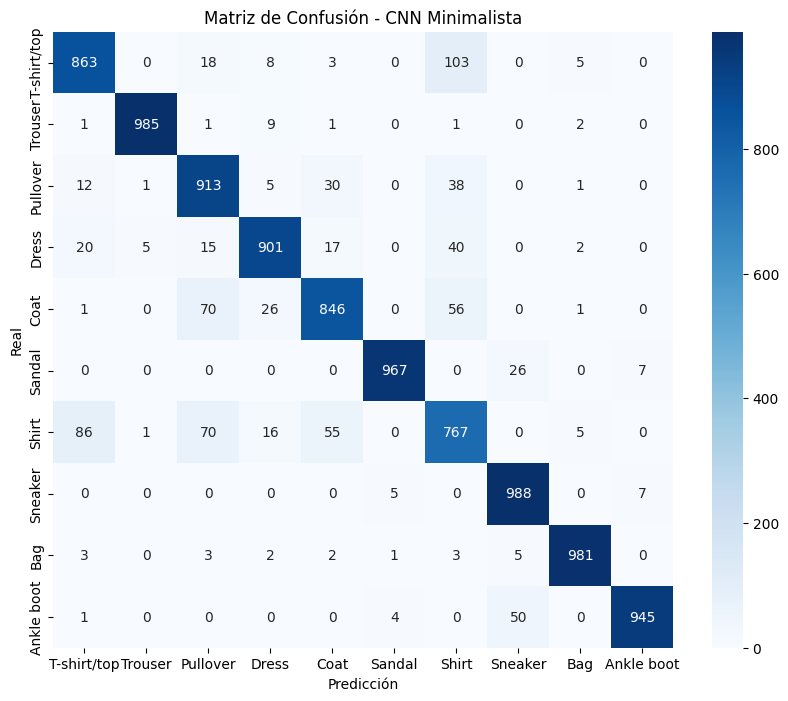

In [13]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

y_pred = np.argmax(model.predict(x_test_3c), axis=1)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión - CNN Minimalista')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

In [14]:
from sklearn.metrics import classification_report, accuracy_score

# 1. Evaluación global del modelo en Test
test_loss, test_acc = model.evaluate(x_test_3c, y_test, verbose=0)
print(f" RESULTADOS GLOBALES EN TEST:")
print(f"Loss: {test_loss:.4f}")
print(f"Accuracy: {test_acc*100:.2f}%")
print("-" * 30)

# 2. Predicciones para análisis detallado
y_pred_probs = model.predict(x_test_3c)
y_pred = np.argmax(y_pred_probs, axis=1)

# 3. Informe de clasificación centrado en T-shirt y Shirt
# Clase 0: T-shirt/top, Clase 6: Shirt
target_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 
                'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

report = classification_report(y_test, y_pred, target_names=target_names)
print(" INFORME DE CLASIFICACIÓN DETALLADO:")
print(report)

# 4. Error específico entre T-shirt y Shirt
errores_tshirt = np.sum((y_test == 0) & (y_pred == 6))
errores_shirt = np.sum((y_test == 6) & (y_pred == 0))

print("-" * 30)
print(f" ANÁLISIS DE FALLO ESPECÍFICO:")
print(f"T-shirts clasificadas como Shirts: {errores_tshirt}")
print(f"Shirts clasificadas como T-shirts: {errores_shirt}")


 RESULTADOS GLOBALES EN TEST:
Loss: 0.1114
Accuracy: 91.56%
------------------------------
313/313 [==============================] - 1s 4ms/step
 INFORME DE CLASIFICACIÓN DETALLADO:
              precision    recall  f1-score   support

 T-shirt/top       0.87      0.86      0.87      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.84      0.91      0.87      1000
       Dress       0.93      0.90      0.92      1000
        Coat       0.89      0.85      0.87      1000
      Sandal       0.99      0.97      0.98      1000
       Shirt       0.76      0.77      0.76      1000
     Sneaker       0.92      0.99      0.96      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.99      0.94      0.96      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000

------------------------------
 ANÁLISIS DE FALLO ESPECÍFI

313/313 [==============================] - 1s 4ms/step


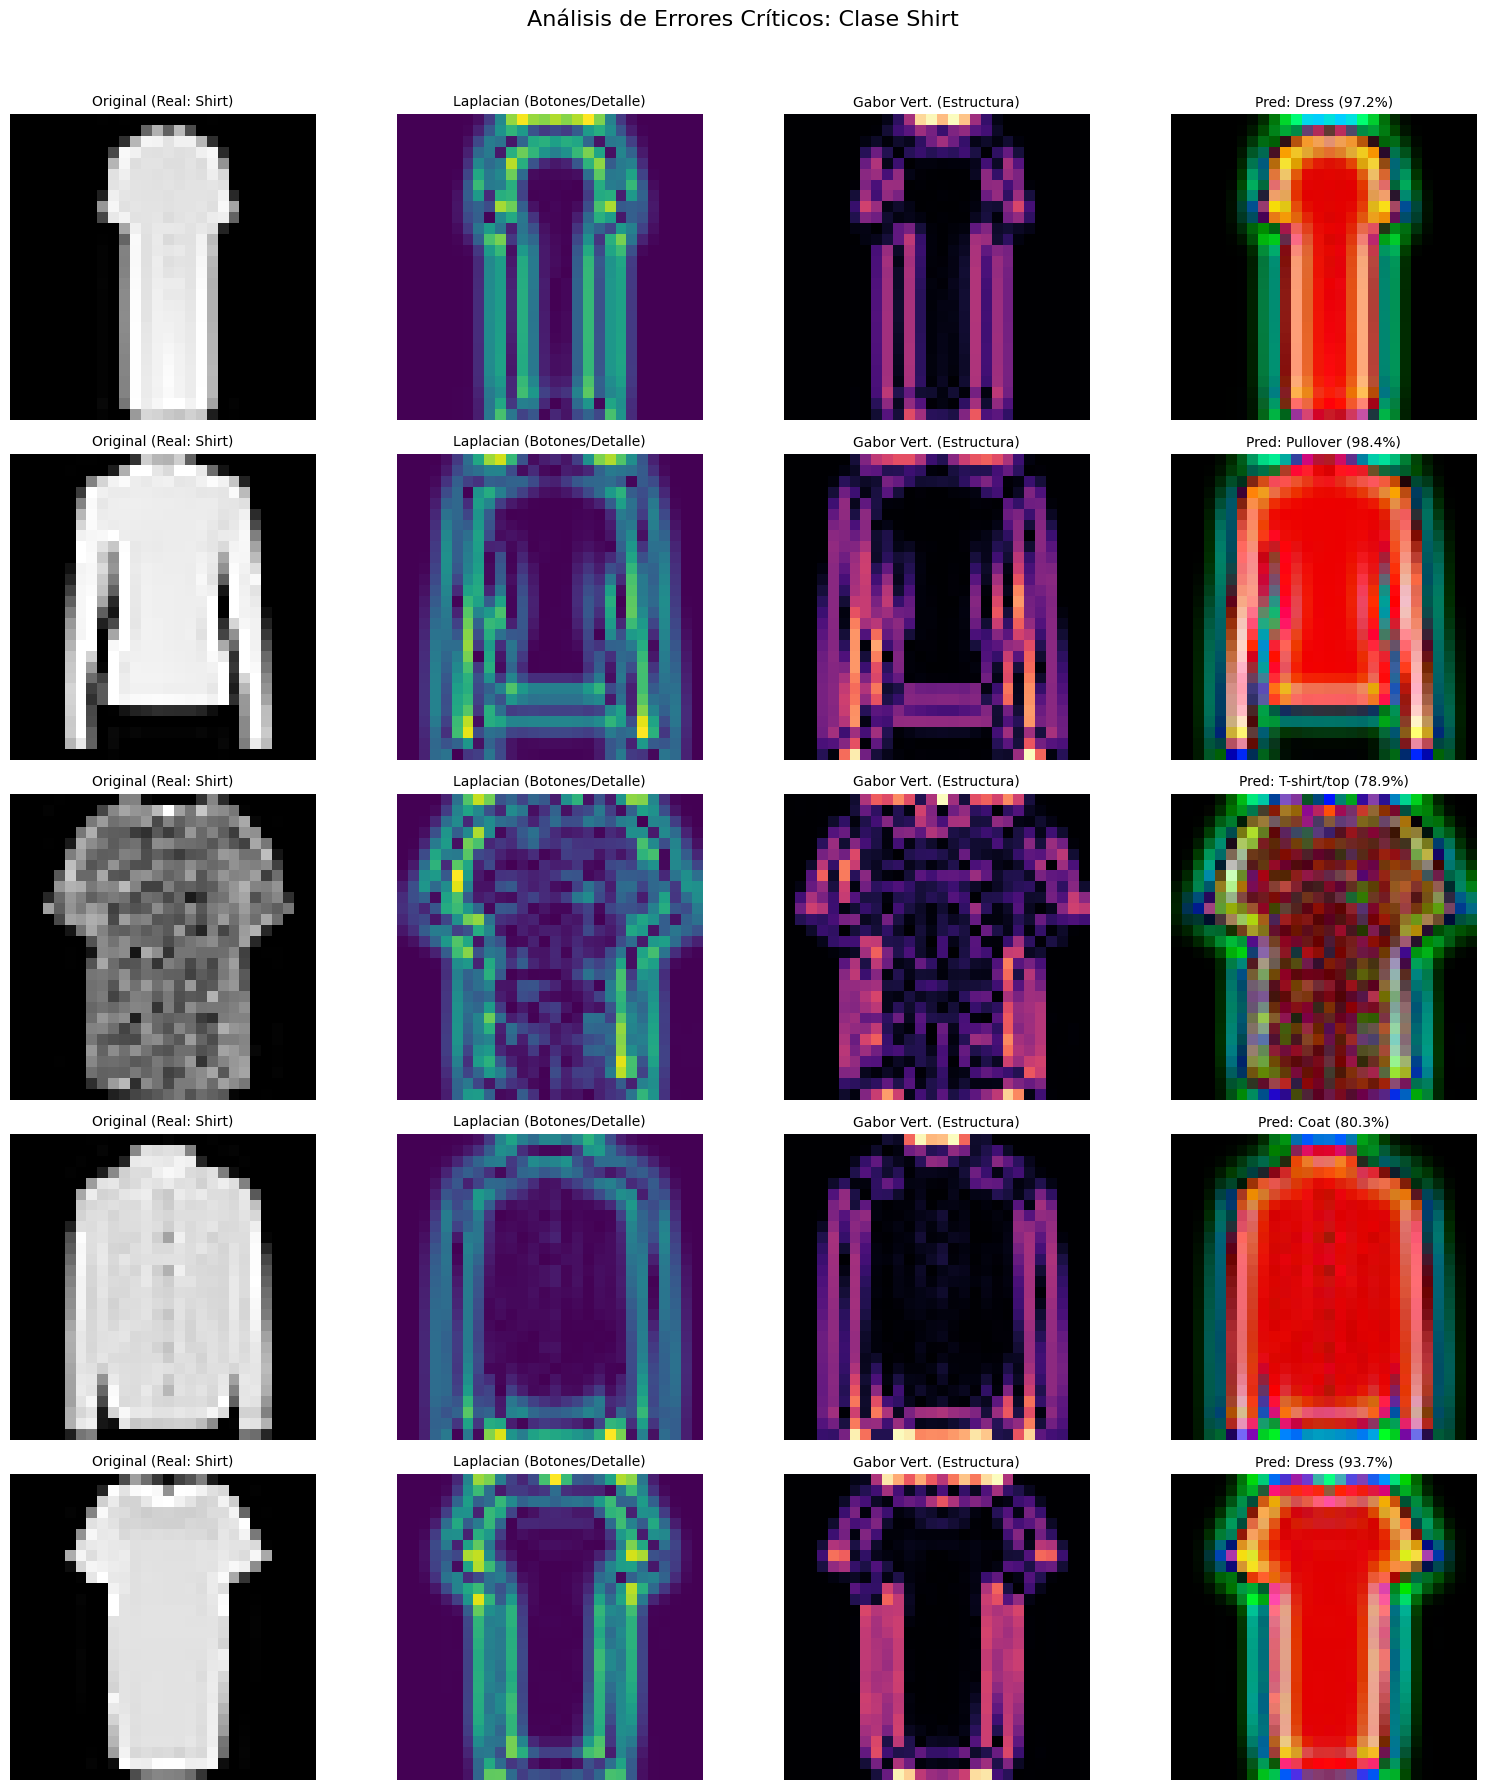

In [15]:
import matplotlib.pyplot as plt
import numpy as np

def visualizar_errores_optimizados(model, x_3c, y_real, class_names, target_class=6, num_images=5):
    # Predicciones del modelo
    preds = model.predict(x_3c)
    pred_labels = np.argmax(preds, axis=1)
    
    # Encontrar índices donde la realidad es la clase objetivo (ej. Shirt) pero el modelo falló
    error_indices = np.where((y_real == target_class) & (pred_labels != target_class))[0]
    
    if len(error_indices) == 0:
        print(f" No hay errores para la clase {class_names[target_class]}")
        return

    plt.figure(figsize=(16, num_images * 3.5))
    
    for i, idx in enumerate(error_indices[:num_images]):
        img_3c = x_3c[idx]
        actual = class_names[y_real[idx]]
        predicha = class_names[pred_labels[idx]]
        confianza = preds[idx][pred_labels[idx]] * 100
        
        # Definir los canales actualizados
        # Canal 0: Original
        # Canal 1: Laplacian (Costuras/Botones)
        # Canal 2: Gabor Vertical (Estructura central)
        
        imgs = [img_3c[:, :, 0], img_3c[:, :, 1], img_3c[:, :, 2], img_3c]
        titles = [
            f'Original (Real: {actual})', 
            'Laplacian (Botones/Detalle)', 
            f'Gabor Vert. (Estructura)',
            f'Pred: {predicha} ({confianza:.1f}%)'
        ]
        cmaps = ['gray', 'viridis', 'magma', None] # Mapas de color optimizados para cada característica
        
        for j in range(4):
            plt.subplot(num_images, 4, i * 4 + j + 1)
            plt.imshow(imgs[j], cmap=cmaps[j])
            plt.title(titles[j], fontsize=10)
            plt.axis('off')
            
    plt.suptitle(f'Análisis de Errores Críticos: Clase {class_names[target_class]}', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# Ejecutar el análisis para la clase 'Shirt' (6)
visualizar_errores_optimizados(model, x_test_3c, y_test, class_names, target_class=6)


313/313 [==============================] - 1s 4ms/step


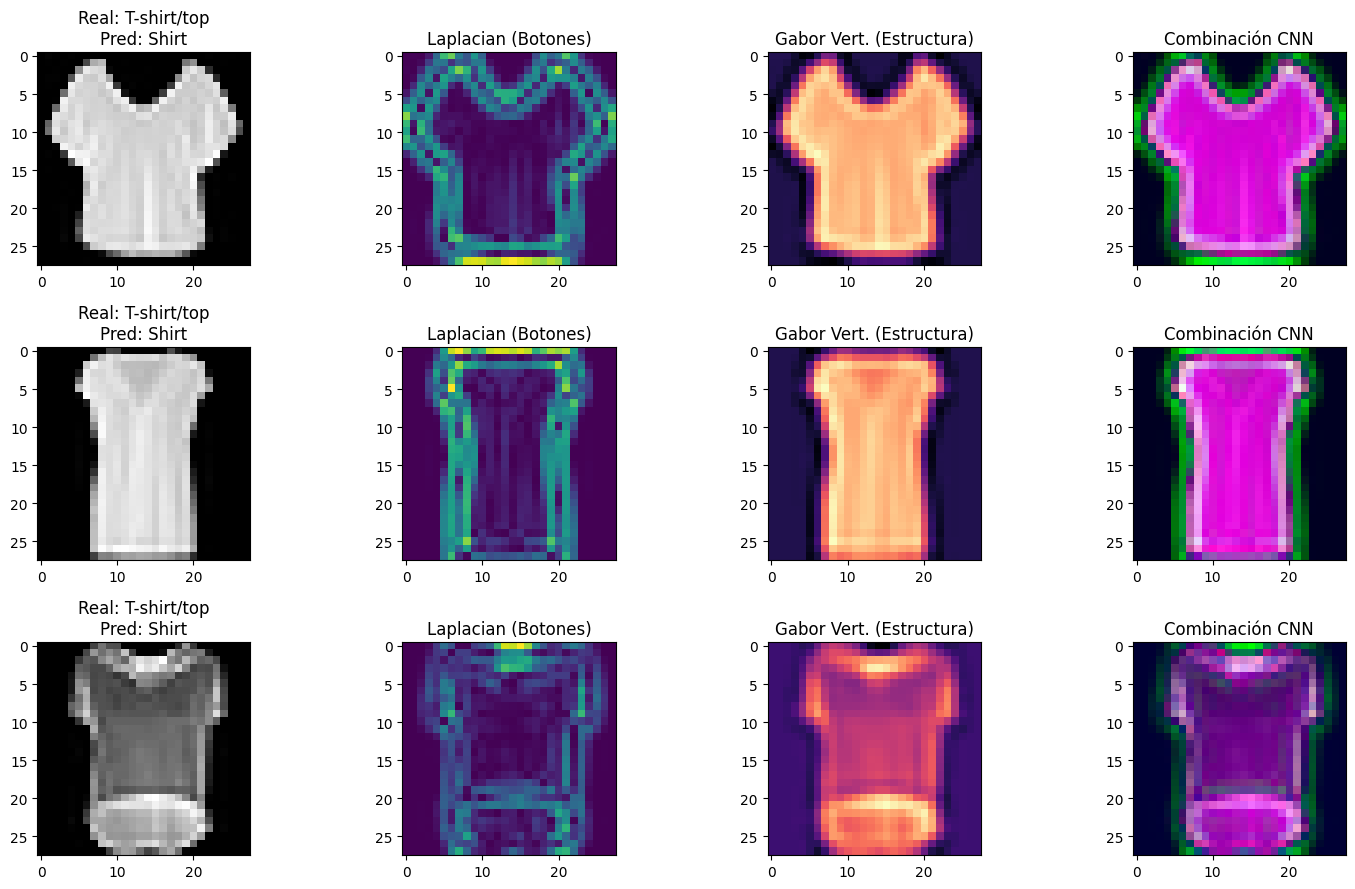

In [19]:
def plot_error_analysis_v2(indices, x_data, y_true, y_pred, class_names):
    n_samples = len(indices)
    fig, axes = plt.subplots(n_samples, 4, figsize=(15, 3 * n_samples))
    for i, idx in enumerate(indices):
        img_3c = x_data[idx]
        # Canal 0
        axes[i, 0].imshow(img_3c[:,:,0], cmap='gray')
        axes[i, 0].set_title(f"Real: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}")
        # Canal 1
        axes[i, 1].imshow(img_3c[:,:,1], cmap='viridis')
        axes[i, 1].set_title("Laplacian (Botones)")
        # Canal 2
        axes[i, 2].imshow(img_3c[:,:,2], cmap='magma')
        axes[i, 2].set_title("Gabor Vert. (Estructura)")
        # RGB
        axes[i, 3].imshow(img_3c)
        axes[i, 3].set_title("Combinación CNN")
    plt.tight_layout()
    plt.show()

# Ejecutar con los nuevos índices de error
y_pred = np.argmax(model.predict(x_test_3c), axis=1)
idx_err = np.where((y_test == 0) & (y_pred == 6))[0][:3] # T-shirt como Shirt
plot_error_analysis_v2(idx_err, x_test_3c, y_test, y_pred, class_names)


## 5. Evaluación Final

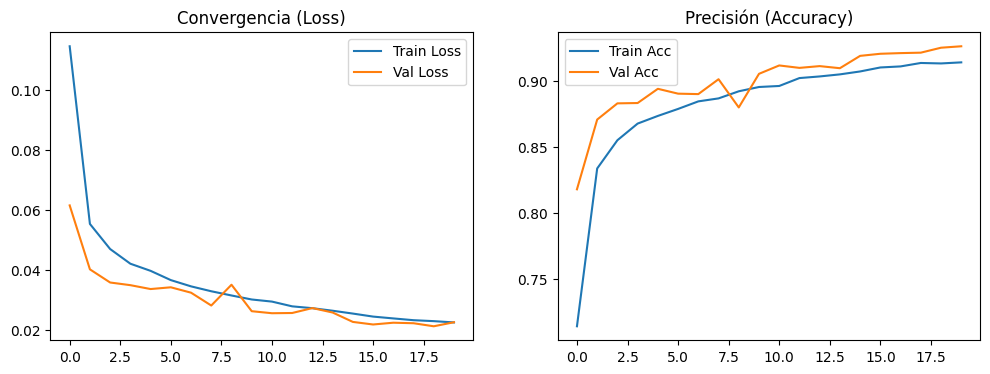

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

--- RESULTADOS FINALES ---
Train Acc: 0.9140 | Val Acc: 0.9262 | Test Acc: 0.9173
Parámetros: 74986


In [5]:
# Curvas de Aprendizaje
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Convergencia (Loss)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Precisión (Accuracy)')
plt.legend()
plt.show()

# Evaluación en Test
y_pred = np.argmax(model.predict(X_test), axis=1)
test_acc = accuracy_score(y_test, y_pred)
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print(f"\n--- RESULTADOS FINALES ---")
print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Test Acc: {test_acc:.4f}")
print(f"Parámetros: {model.count_params()}")

## Resumen de Resultados - CNN atencion

| Modelo | Parámetros |Train Acc | Val Acc | Test Acc
| :--- | :---: | :---: | :---: |:---
| **CNN atencion** | 74986 | 0.9140 | 0.9262 | 0.9173

### Análisis del Modelo CNN atención

Hemos construido una Red CNN con atención.

Obtenemos buenos resultados en casi todas las clases logrando aproximadamente un 93% de accuracy. Hay un problema con la clases Shirt y T-shirt/Top.
Al tener poca resolución la imágenes es difócil que el modelo encuentre detalles con los que generalizar. También, la clase T-shirt/Top puede ser ambigua, ya que al contener dos tipo de prendas el modelo no llega a capturar bien la informacion del todo, podría ser interesante separar en 2 clases.
Dada la calidad de los datos, el modelo parece haber llega a su techo ya que al usar modelo más complejos tenemos los mismos resultados y problemas por lo que el problema no es tanto mejorar la arquitectura del modelo sino ver qué imágenes le cuestan más al modelo o aquellas que pueden estar causando ambigüedad. Una posible mejora para intentar mejorar un poco más los resultados podría ser la eliminación de aquellos ejemplos que no son representativos, ya que hay varias imágenes que no son distinguibles al ojo humano.
